In [1]:
#reading file 
import pandas as pd
with open('EV_sales.csv') as E:
    ev=pd.read_csv(E)
ev

,RecordID,Year,State,Manufacturer,VehicleType,EVSales,BatteryCapacity
0,1,2021,Andhra Pradesh,BYD,Electric Scooter,2106,30
1,2,2022,Gujarat,Tata,Electric Bike,4567,13
2,3,2025,Tamil Nadu,Tata,Electric Car,867,29
3,4,2022,Maharashtra,Mahindra,Electric Car,4697,27
4,5,2025,Tamil Nadu,Ola,Electric Scooter,4927,37
...,...,...,...,...,...,...,...
145,146,2021,Andhra Pradesh,MG,Electric Scooter,706,75
146,147,2021,Telangana,Ola,Electric Bike,2589,12
147,148,2022,Andhra Pradesh,Mahindra,Electric Scooter,4983,30
148,149,2025,Tamil Nadu,MG,Electric Scooter,2535,56


In [2]:
#displaying first 5 recording
ev.head(5)

,RecordID,Year,State,Manufacturer,VehicleType,EVSales,BatteryCapacity
0,1,2021,Andhra Pradesh,BYD,Electric Scooter,2106,30
1,2,2022,Gujarat,Tata,Electric Bike,4567,13
2,3,2025,Tamil Nadu,Tata,Electric Car,867,29
3,4,2022,Maharashtra,Mahindra,Electric Car,4697,27
4,5,2025,Tamil Nadu,Ola,Electric Scooter,4927,37


In [3]:
#displaying first 5 recording
ev.tail(5)

,RecordID,Year,State,Manufacturer,VehicleType,EVSales,BatteryCapacity
145,146,2021,Andhra Pradesh,MG,Electric Scooter,706,75
146,147,2021,Telangana,Ola,Electric Bike,2589,12
147,148,2022,Andhra Pradesh,Mahindra,Electric Scooter,4983,30
148,149,2025,Tamil Nadu,MG,Electric Scooter,2535,56
149,150,2023,Maharashtra,Mahindra,Electric Car,912,28


### Basic analysis
1. What is the shape of the dataset?
2. What are the column names?
3.  What are the data types of each column?
4.  What is the summary statistics of the dataset?
5.  How many unique manufacturers are present?

In [4]:
#1. What is the shape of the dataset?
print(f"Shape of the Dataset is{ev.shape}")

Shape of the Dataset is(150, 7)


In [5]:
#2. What are the column names?
print(f"The column names of the Dataset are")
ev.columns

The column names of the Dataset are


Index(['RecordID', 'Year', 'State', 'Manufacturer', 'VehicleType', 'EVSales',
       'BatteryCapacity'],
      dtype='object')

In [6]:
#3.  What are the data types of each column?
print(f"Data type of each column")
ev.dtypes

Data type of each column


RecordID            int64
Year                int64
State              object
Manufacturer       object
VehicleType        object
EVSales             int64
BatteryCapacity     int64
dtype: object

In [7]:
#4.  What is the summary statistics of the dataset?
ev.describe()

,RecordID,Year,EVSales,BatteryCapacity
count,150.000000,150.000000,150.000000,150.000000
mean,75.500000,2023.026667,2635.513333,37.493333
std,43.445368,1.394845,1418.464619,20.730533
min,1.000000,2021.000000,145.000000,2.000000
25%,38.250000,2022.000000,1348.750000,22.000000
50%,75.500000,2023.000000,2600.000000,35.000000
75%,112.750000,2024.000000,3967.000000,56.000000
max,150.000000,2025.000000,4988.000000,75.000000


In [8]:
#5.  How many unique manufacturers are present?
ev["Manufacturer"].nunique()


6

In [9]:
# printing unique manufacturers
for i in ev["Manufacturer"].unique():
    print(i)

BYD
Tata
Mahindra
Ola
Ather
MG


###  Data cleaning 
 6. Are there any missing values in the dataset?
 7. Are there any duplicate records in the dataset?
 8. Are there any inconsistent manufacturer names?
 9. Are there any invalid model years?
 10. Are there any missing or unknown vehicle types
 11. . Are there any inconsistent state, city, or county names?

In [10]:
# 6. Are there any missing values in the dataset?
if any(ev.isnull().sum()):
    print("Yes")
else :
    print("No")

No


In [11]:
ev.isnull().sum()

RecordID           0
Year               0
State              0
Manufacturer       0
VehicleType        0
EVSales            0
BatteryCapacity    0
dtype: int64

In [12]:
# 7. Are there any duplicate records in the dataset?
if ev.duplicated().any():
    print("Yes")
else:
    print("NO")

NO


In [13]:
ev.duplicated().sum()

np.int64(0)

In [14]:
#8.Are there any inconsistent manufacturer names?
ev["Manufacturer"].unique()

array(['BYD', 'Tata', 'Mahindra', 'Ola', 'Ather', 'MG'], dtype=object)

In [15]:
if all(ev["Manufacturer"].unique()):
    print("Yes")
else:
    print("No")

Yes


In [16]:
#9. Are there any invalid model years?
ev["Year"].describe()

count     150.000000
mean     2023.026667
std         1.394845
min      2021.000000
25%      2022.000000
50%      2023.000000
75%      2024.000000
max      2025.000000
Name: Year, dtype: float64

In [17]:
#10. Are there any missing or unknown vehicle types?
ev["VehicleType"].value_counts()

VehicleType
Electric Scooter    51
Electric Car        51
Electric Bike       48
Name: count, dtype: int64

In [18]:
#11. Are there any inconsistent state, city, or county names?
if all(ev["State"].unique()):
    print("Yes")
else:
    print("No")


Yes


In [19]:
for i in ev["State"].unique():
    print(i)

Andhra Pradesh
Gujarat
Tamil Nadu
Maharashtra
Telangana
Karnataka


### Data Filtering
12. Which records belong to Andhra Pradesh?
13. Which vehicles have EV sales greater than 3000?
14. Which records correspond to Electric Cars?
15. Which Tata vehicles were sold in 2024?
16. Which vehicles have battery capacity greater than 50 kWh?


In [20]:
#12. Which records belong to Andhra Pradesh?
ev[ev["State"]=="Andhra Pradesh"]

,RecordID,Year,State,Manufacturer,VehicleType,EVSales,BatteryCapacity
0,1,2021,Andhra Pradesh,BYD,Electric Scooter,2106,30
10,11,2021,Andhra Pradesh,BYD,Electric Car,2470,12
11,12,2022,Andhra Pradesh,MG,Electric Scooter,3814,48
15,16,2023,Andhra Pradesh,Ola,Electric Car,2684,53
16,17,2023,Andhra Pradesh,Ola,Electric Bike,2677,29
23,24,2025,Andhra Pradesh,BYD,Electric Bike,1038,70
28,29,2025,Andhra Pradesh,Mahindra,Electric Scooter,4102,4
30,31,2025,Andhra Pradesh,Tata,Electric Bike,4081,10
35,36,2022,Andhra Pradesh,Ather,Electric Car,4919,72
37,38,2022,Andhra Pradesh,Tata,Electric Scooter,680,67


In [21]:
#13. Which vehicles have EV sales greater than 3000?
ev[ev["EVSales"]>3000]

,RecordID,Year,State,Manufacturer,VehicleType,EVSales,BatteryCapacity
1,2,2022,Gujarat,Tata,Electric Bike,4567,13
3,4,2022,Maharashtra,Mahindra,Electric Car,4697,27
4,5,2025,Tamil Nadu,Ola,Electric Scooter,4927,37
9,10,2023,Gujarat,Mahindra,Electric Scooter,4829,26
11,12,2022,Andhra Pradesh,MG,Electric Scooter,3814,48
14,15,2024,Tamil Nadu,Ather,Electric Bike,4662,30
18,19,2022,Telangana,BYD,Electric Bike,4515,35
19,20,2025,Tamil Nadu,Mahindra,Electric Scooter,3065,30
21,22,2022,Gujarat,Ola,Electric Bike,3558,10
22,23,2024,Tamil Nadu,Mahindra,Electric Scooter,4434,34


In [22]:
#14. Which records correspond to Electric Cars?
ev[ev["VehicleType"]=="Electric Car"]

,RecordID,Year,State,Manufacturer,VehicleType,EVSales,BatteryCapacity
2,3,2025,Tamil Nadu,Tata,Electric Car,867,29
3,4,2022,Maharashtra,Mahindra,Electric Car,4697,27
6,7,2022,Telangana,Ather,Electric Car,859,50
10,11,2021,Andhra Pradesh,BYD,Electric Car,2470,12
12,13,2022,Karnataka,Ather,Electric Car,2287,11
15,16,2023,Andhra Pradesh,Ola,Electric Car,2684,53
20,21,2022,Maharashtra,MG,Electric Car,485,16
24,25,2023,Gujarat,Ather,Electric Car,2504,57
29,30,2021,Karnataka,Ather,Electric Car,574,32
33,34,2025,Gujarat,BYD,Electric Car,2653,53


In [23]:
#15. Which Tata vehicles were sold in 2024?
ev[(ev["Manufacturer"]=="Tata") & (ev["Year"]==2024)]

,RecordID,Year,State,Manufacturer,VehicleType,EVSales,BatteryCapacity
8,9,2024,Maharashtra,Tata,Electric Scooter,745,72
65,66,2024,Karnataka,Tata,Electric Car,2832,18
133,134,2024,Andhra Pradesh,Tata,Electric Scooter,1915,53


In [24]:
#16. Which vehicles have battery capacity greater than 50 kWh?
ev[ev["BatteryCapacity"]>50]

,RecordID,Year,State,Manufacturer,VehicleType,EVSales,BatteryCapacity
8,9,2024,Maharashtra,Tata,Electric Scooter,745,72
15,16,2023,Andhra Pradesh,Ola,Electric Car,2684,53
23,24,2025,Andhra Pradesh,BYD,Electric Bike,1038,70
24,25,2023,Gujarat,Ather,Electric Car,2504,57
25,26,2022,Tamil Nadu,Tata,Electric Bike,2257,66
26,27,2022,Maharashtra,Tata,Electric Bike,2544,66
27,28,2025,Telangana,Ola,Electric Scooter,1423,71
31,32,2025,Telangana,Ola,Electric Bike,3993,72
33,34,2025,Gujarat,BYD,Electric Car,2653,53
35,36,2022,Andhra Pradesh,Ather,Electric Car,4919,72


### Grouping
17. What is the total EV sales for each manufacturer?
18. What is the average EV sales for each state?
19. What is the total EV sales for each vehicle type?
20. What is the total EV sales in each year?
21. What is the average battery capacity for each manufacturer?

In [25]:
#17. What is the total EV sales for each manufacturer?
ev.groupby("Manufacturer")["EVSales"].sum().reset_index()

,Manufacturer,EVSales
0,Ather,69996
1,BYD,70180
2,MG,48237
3,Mahindra,89843
4,Ola,63383
5,Tata,53688


In [26]:
#18. What is the average EV sales for each state?
ev.groupby("State")["EVSales"].mean().round().reset_index().rename(columns={"EVSales":"Average_sales"})

,State,Average_sales
0,Andhra Pradesh,2716.0
1,Gujarat,2917.0
2,Karnataka,2201.0
3,Maharashtra,2523.0
4,Tamil Nadu,2667.0
5,Telangana,2664.0


In [27]:
#19. What is the total EV sales for each vehicle type?
ev.groupby("VehicleType")["EVSales"].sum().reset_index().rename(columns={"EVSales":"Total sales"})

,VehicleType,Total sales
0,Electric Bike,135626
1,Electric Car,119444
2,Electric Scooter,140257


In [28]:
#20. What is the total EV sales in each year?
ev.groupby("Year")["EVSales"].sum().reset_index().rename(columns={"EVSales":"Total sales"})

,Year,Total sales
0,2021,66001
1,2022,94342
2,2023,71154
3,2024,94567
4,2025,69263


In [29]:
#21. What is the average battery capacity for each manufacturer?
ev.groupby("Manufacturer")["BatteryCapacity"].mean().reset_index().rename(columns={"BatteryCapacity":"Average Battery Capacity"})

,Manufacturer,Average Battery Capacity
0,Ather,30.115385
1,BYD,39.428571
2,MG,44.250000
3,Mahindra,41.379310
4,Ola,38.230769
5,Tata,31.333333


###  Sorting
22. What are the top 10 highest EV sales records?
23. What are the bottom 10 EV sales records?
24. Which manufacturers rank highest to lowest in total sales?
25. Which states rank highest to lowest in total EV sales?
26. Which vehicle types rank highest to lowest in total sales?

In [30]:
#22. What are the top 10 highest EV sales records?
ev.sort_values(by="EVSales",ascending=False).head(10).reset_index(drop=True)

,RecordID,Year,State,Manufacturer,VehicleType,EVSales,BatteryCapacity
0,140,2023,Gujarat,Mahindra,Electric Bike,4988,38
1,131,2023,Karnataka,Ather,Electric Scooter,4983,37
2,148,2022,Andhra Pradesh,Mahindra,Electric Scooter,4983,30
3,98,2024,Gujarat,Mahindra,Electric Bike,4977,42
4,5,2025,Tamil Nadu,Ola,Electric Scooter,4927,37
5,36,2022,Andhra Pradesh,Ather,Electric Car,4919,72
6,55,2025,Andhra Pradesh,MG,Electric Bike,4881,74
7,79,2021,Andhra Pradesh,Ather,Electric Car,4856,35
8,10,2023,Gujarat,Mahindra,Electric Scooter,4829,26
9,118,2022,Tamil Nadu,BYD,Electric Car,4720,29


In [31]:
#23. What are the bottom 10 EV sales records?
ev.sort_values(by="EVSales",ascending=False).tail(10).reset_index(drop=True)

,RecordID,Year,State,Manufacturer,VehicleType,EVSales,BatteryCapacity
0,116,2025,Andhra Pradesh,Ather,Electric Car,662,7
1,53,2021,Maharashtra,Tata,Electric Car,661,10
2,30,2021,Karnataka,Ather,Electric Car,574,32
3,42,2023,Tamil Nadu,MG,Electric Scooter,543,14
4,65,2023,Maharashtra,MG,Electric Scooter,516,13
5,21,2022,Maharashtra,MG,Electric Car,485,16
6,70,2022,Andhra Pradesh,Ather,Electric Scooter,426,47
7,111,2024,Telangana,Mahindra,Electric Bike,320,52
8,120,2022,Karnataka,Tata,Electric Bike,310,41
9,95,2024,Tamil Nadu,Ola,Electric Car,145,15


In [32]:
#24. Which manufacturers rank highest to lowest in total sales?
ev.groupby("Manufacturer")[["EVSales"]].sum().sort_values(by="EVSales",ascending=False).reset_index()

,Manufacturer,EVSales
0,Mahindra,89843
1,BYD,70180
2,Ather,69996
3,Ola,63383
4,Tata,53688
5,MG,48237


In [33]:
#25. Which states rank highest to lowest in total EV sales?
ev.groupby("State")[["EVSales"]].sum().sort_values(by="EVSales",ascending=False).reset_index()

,State,EVSales
0,Tamil Nadu,88012
1,Andhra Pradesh,86896
2,Gujarat,70000
3,Telangana,55953
4,Maharashtra,50455
5,Karnataka,44011


In [34]:
#26. Which vehicle types rank highest to lowest in total sales?
ev.groupby("VehicleType")["EVSales"].sum().sort_values(ascending=False).reset_index()

,VehicleType,EVSales
0,Electric Scooter,140257
1,Electric Bike,135626
2,Electric Car,119444


### Aggregations (Min, Max, Mean, Mode, Variance,Standard Deviation)
27. What is the minimum EV sales value in the dataset?
28. What is the maximum EV sales value in the dataset?
29. What is the average EV sales value?
30. What is the mode of EV sales?
31. What is the variance of EV sales?
32. What is the Standard Deviation of EV sales? 

In [35]:

S=ev["EVSales"]
print(f"27.Max EVSales : {S.max()}")
print(f"\n28.Min EVSales : {S.min()}")
print(f"\n29.Average EVSales : {S.mean().round()}")
print(f"\n30.mode of EVSales\n{S.mode()}")
print(f"\n31.variance of EVSales : {round(S.var(),2)}")
print(f"\n32.Standard Deviation of EVSales : {round(S.std(),2)}")





27.Max EVSales : 4988

28.Min EVSales : 145

29.Average EVSales : 2636.0

30.mode of EVSales
0    2589
1    2684
2    3204
3    4078
4    4983
Name: EVSales, dtype: int64

31.variance of EVSales : 2012041.88

32.Standard Deviation of EVSales : 1418.46


### Analytical Queries
33. Which state has the highest total EV sales?
34. Which manufacturer has the highest total EV sales?
35. Which vehicle type contributes the most to total EV sales?
36. What is the total EV sales for each state-manufacturer combination?
37. Which year recorded the highest total EV sales?

In [36]:
#33. Which state has the highest total EV sales?
ev.groupby("State")["EVSales"].sum().idxmax()

'Tamil Nadu'

In [37]:
print(ev.groupby("State")["EVSales"].sum().loc[lambda x:[x.idxmax()]])


State
Tamil Nadu    88012
Name: EVSales, dtype: int64


In [38]:
#34. Which manufacturer has the highest total EV sales?
ev.groupby("Manufacturer")["EVSales"].sum().idxmax()

'Mahindra'

In [39]:
#print along with the valuee
ev.groupby("Manufacturer")["EVSales"].sum().loc[lambda x:[x.idxmax()]]


Manufacturer
Mahindra    89843
Name: EVSales, dtype: int64

In [40]:
#35. Which vehicle type contributes the most to total EV sales?
ev.groupby("VehicleType")["EVSales"].sum().idxmax()

'Electric Scooter'

In [41]:
ev.groupby("VehicleType")["EVSales"].sum().loc[lambda x: [x.idxmax()]]

VehicleType
Electric Scooter    140257
Name: EVSales, dtype: int64

In [42]:
#36. What is the total EV sales for each state-manufacturer combination?
ev.groupby(["State","Manufacturer"])["EVSales"].sum()

State           Manufacturer
Andhra Pradesh  Ather           10863
                BYD             13478
                MG               9401
                Mahindra        20840
                Ola             11085
                Tata            21229
Gujarat         Ather           13433
                BYD              5872
                MG               5860
                Mahindra        25927
                Ola             10019
                Tata             8889
Karnataka       Ather           16278
                BYD              9590
                MG               4282
                Mahindra         4879
                Ola              2168
                Tata             6814
Maharashtra     Ather            8053
                BYD             10529
                MG               5451
                Mahindra        12772
                Ola              9700
                Tata             3950
Tamil Nadu      Ather           13376
                BYD  

In [43]:
#37. Which year recorded the highest total EV sales?
ev.groupby("Year")["EVSales"].sum().idxmax()

np.int64(2024)

### Data Visualization
38. How has EV sales changed over the years? => Line Chart
39. Which manufacturer contributes the highest EV sales? => Bar Char
40. Which states have the highest and lowest EV sales?=>Horizontal Bar Chart
41. What is the distribution of vehicle types in the dataset? => Pie Chart
42. How are battery capacities distributed among EVs? => Histogram
43. Is there any relationship between battery capacity and EV sales? => Scatter Plot

In [44]:
import matplotlib.pyplot as plt

In [45]:
#38. How has EV sales changed over the years? => Line Chart
sales_yearly=ev.groupby("Year")["EVSales"].sum().reset_index()
sales_yearly



,Year,EVSales
0,2021,66001
1,2022,94342
2,2023,71154
3,2024,94567
4,2025,69263


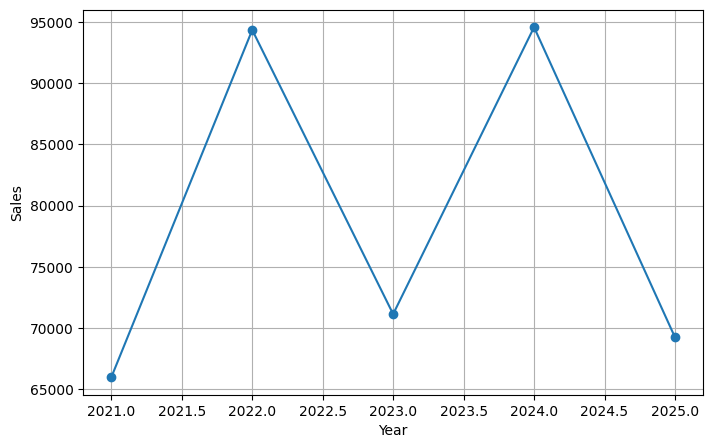

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(sales_yearly["Year"],sales_yearly["EVSales"],marker='o',linestyle='-')
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [47]:
#39. Which manufacturer contributes the highest EV sales? => Bar Char
highest_sales=ev.groupby("Manufacturer")["EVSales"].sum().reset_index()
highest_sales

,Manufacturer,EVSales
0,Ather,69996
1,BYD,70180
2,MG,48237
3,Mahindra,89843
4,Ola,63383
5,Tata,53688


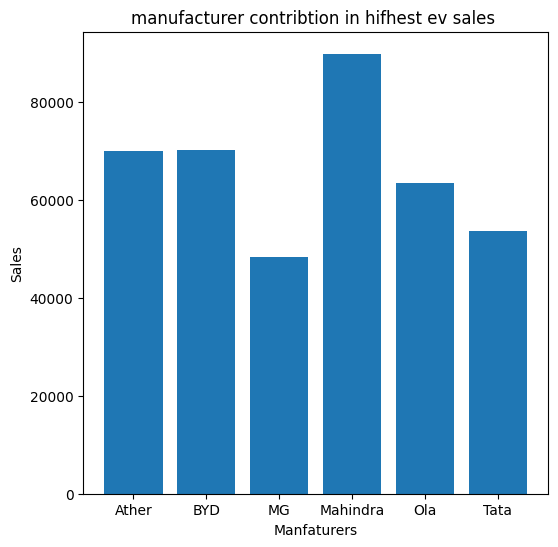

In [48]:
plt.figure(figsize=(6,6))
plt.bar(highest_sales["Manufacturer"],highest_sales["EVSales"])
plt.xlabel("Manfaturers")
plt.ylabel("Sales")
plt.title("manufacturer contribtion in hifhest ev sales ")
plt.show()

In [49]:
#40. Which states have the highest and lowest EV sales?=>Horizontal Bar Chart
state_sales=ev.groupby("State")["EVSales"].sum().reset_index()
state_sales

,State,EVSales
0,Andhra Pradesh,86896
1,Gujarat,70000
2,Karnataka,44011
3,Maharashtra,50455
4,Tamil Nadu,88012
5,Telangana,55953


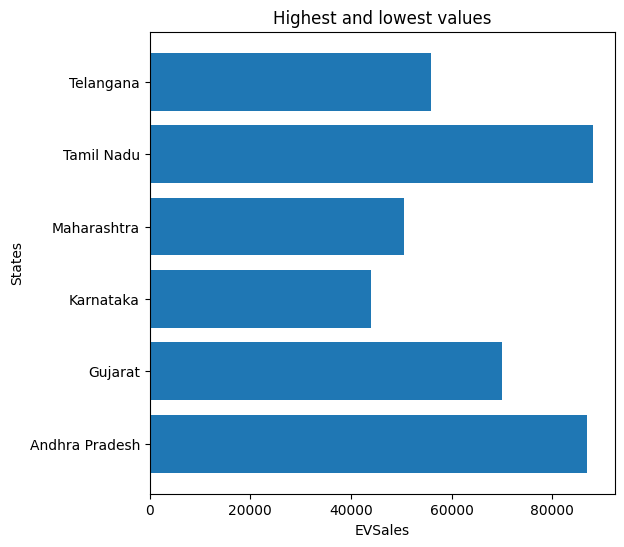

In [50]:
plt.figure(figsize=(6,6))
plt.barh(state_sales["State"],state_sales["EVSales"])
plt.ylabel("States")
plt.xlabel("EVSales")
plt.title("Highest and lowest values")
plt.show()

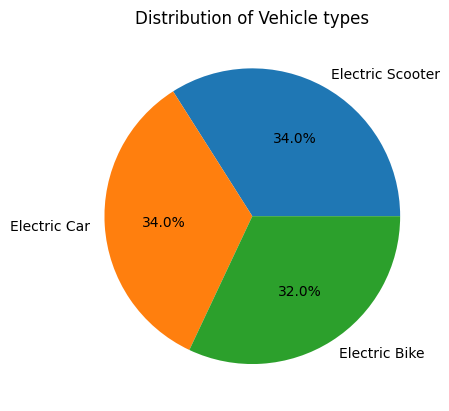

In [51]:
#41. What is the distribution of vehicle types in the dataset? => Pie Chart
vehicle_types=ev["VehicleType"].value_counts()
plt.pie(vehicle_types,
       labels=vehicle_types.index,
       autopct='%1.1f%%')
plt.title("Distribution of Vehicle types")
plt.show()

In [52]:
#42. How are battery capacities distributed among EVs? => Histogram
battery_capacities=ev["BatteryCapacity"].value_counts().reset_index()
battery_capacities

,BatteryCapacity,count
0,32,7
1,29,6
2,37,6
3,30,5
4,35,5
5,57,4
6,22,4
7,72,4
8,63,4
9,44,4


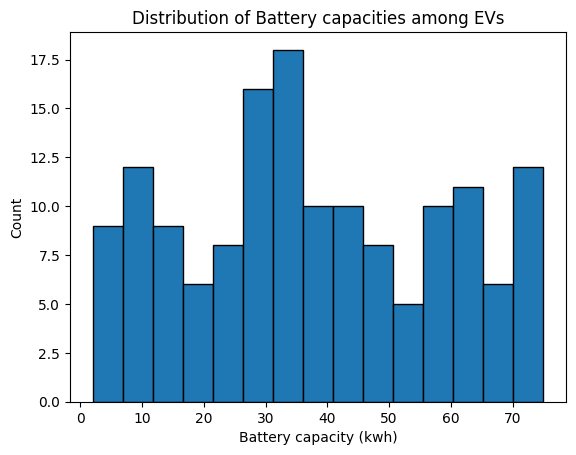

In [53]:
plt.hist(ev["BatteryCapacity"],bins=15,edgecolor="black")
plt.xlabel("Battery capacity (kwh)")
plt.ylabel("Count")
plt.title("Distribution of Battery capacities among EVs")
plt.show()

### Seaborn
43. Is there any relationship between battery capacity and EV sales? => Scatter Plot
44. Which EV manufacturer has the highest number of vehicles? => count plot
45. How does electric range vary among different vehicle types? => box plot
46. What is the distribution of electric range in the dataset? => Histplot
47. Create a heatmap showing correlations between numerical columns.

In [54]:
#43. Is there any relationship between battery capacity and EV sales? => Scatter Plot
relation=ev.groupby("BatteryCapacity")["EVSales"].sum().reset_index()
relation

,BatteryCapacity,EVSales
0,2,6876
1,3,8961
2,4,11344
3,5,6004
4,7,5044
5,9,5233
6,10,8300
7,11,8003
8,12,5059
9,13,5083


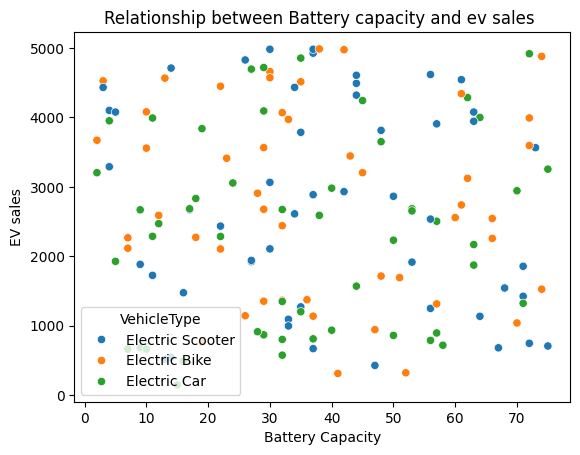

In [55]:
import seaborn as sns
sns.scatterplot(data=ev,
               x="BatteryCapacity",
               y="EVSales",
               hue="VehicleType"
               )
plt.xlabel("Battery Capacity")
plt.ylabel("EV sales")
plt.title("Relationship between Battery capacity and ev sales ")
plt.show()

In [58]:
ev

,RecordID,Year,State,Manufacturer,VehicleType,EVSales,BatteryCapacity
0,1,2021,Andhra Pradesh,BYD,Electric Scooter,2106,30
1,2,2022,Gujarat,Tata,Electric Bike,4567,13
2,3,2025,Tamil Nadu,Tata,Electric Car,867,29
3,4,2022,Maharashtra,Mahindra,Electric Car,4697,27
4,5,2025,Tamil Nadu,Ola,Electric Scooter,4927,37
...,...,...,...,...,...,...,...
145,146,2021,Andhra Pradesh,MG,Electric Scooter,706,75
146,147,2021,Telangana,Ola,Electric Bike,2589,12
147,148,2022,Andhra Pradesh,Mahindra,Electric Scooter,4983,30
148,149,2025,Tamil Nadu,MG,Electric Scooter,2535,56


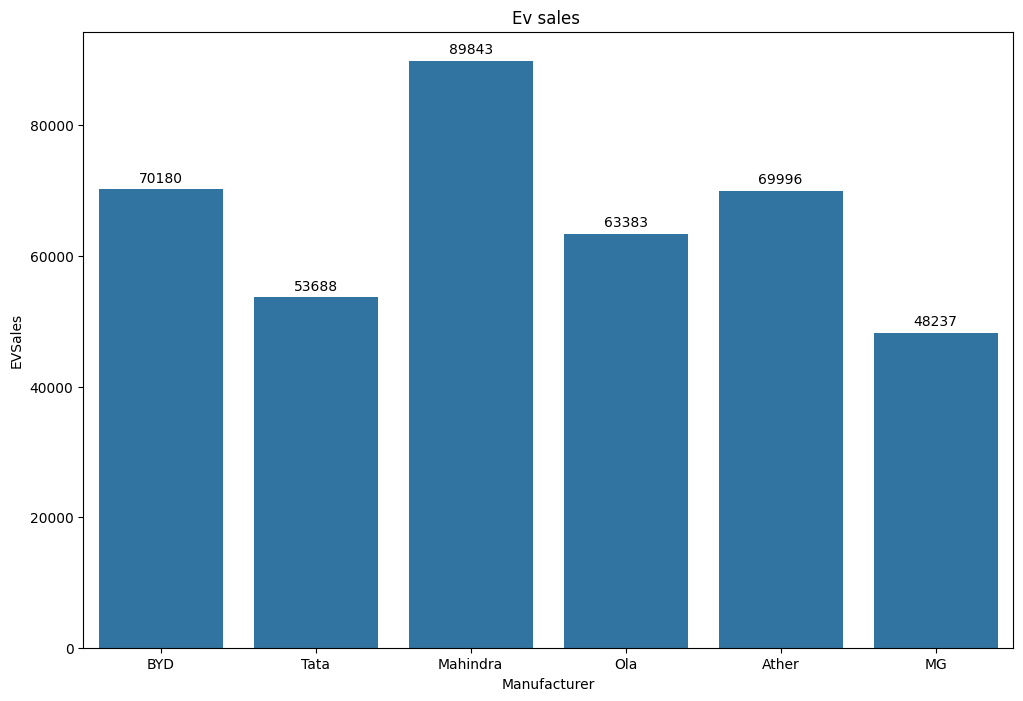

In [73]:
#44. Which EV manufacturer has the highest number of vehicles Sales? => barplot
plt.figure(figsize=(12,8))
ax =sns.barplot(data=ev,
             x="Manufacturer",
             y="EVSales",
           estimator=sum,
               errorbar=None)
ax.bar_label(ax.containers[0],
            fmt='%d',
            padding=3)
plt.title("Ev sales ")
plt.show()

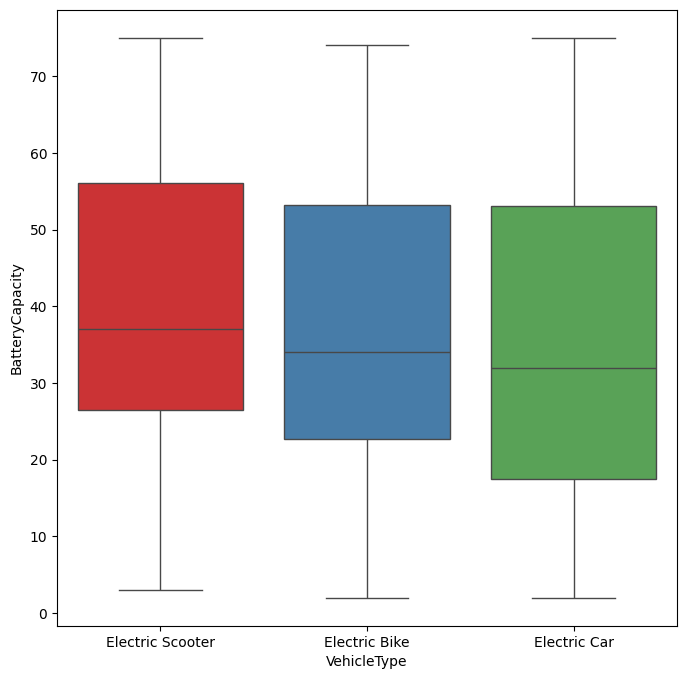

In [93]:
#45. How does battery capacity vary among different vehicle types? => box plot
plt.figure(figsize=(8,8))
ax=sns.boxplot(data=ev,
              x="VehicleType",
              y="BatteryCapacity",
               hue="VehicleType",
               legend=False,
              palette="Set1")
plt.show()

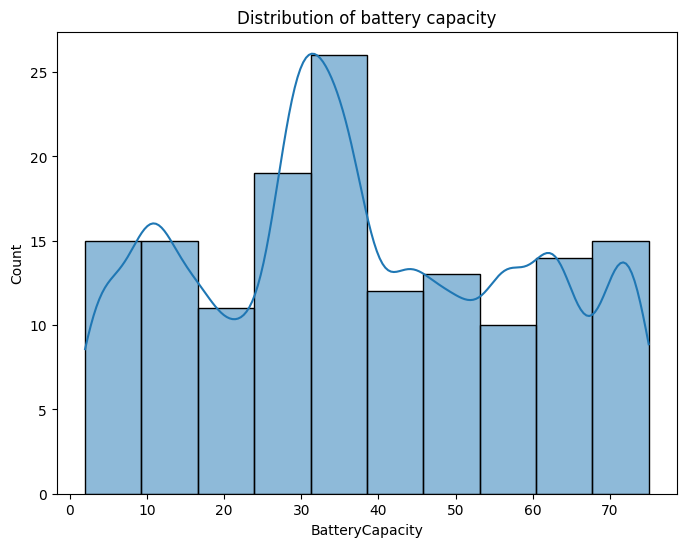

In [122]:
#46. What is the distribution of battery capacity in the dataset? => Histplot
plt.figure(figsize=(8,6))
sns.histplot(
    data=ev,
    x="BatteryCapacity",
    kde=True,
    bins=10,
    kde_kws={'bw_adjust':0.35}
)
plt.title("Distribution of battery capacity")
plt.show()


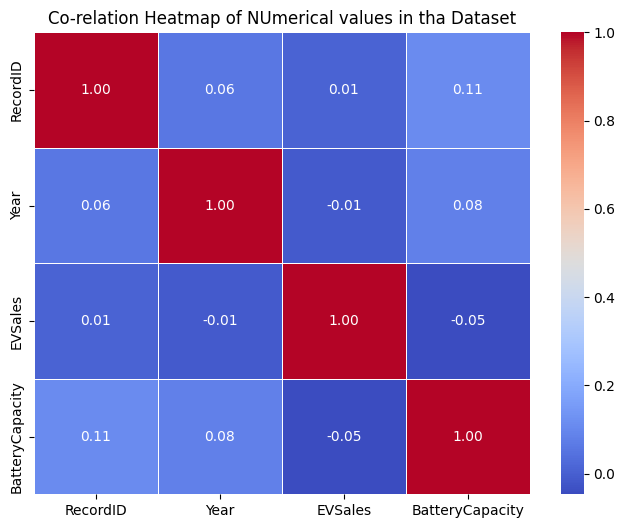

In [134]:
#47. Create a heatmap showing correlations between numerical columns.
plt.figure(figsize=(8,6))
x=ev.select_dtypes(include=["number"])
matrix=x.corr()

sns.heatmap(
    matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Co-relation Heatmap of NUmerical values in tha Dataset")
plt.show()